# 5. Model Evaluation

*Proposal section 3.2.4.* Evaluates the tuned models from `04_model_training` on the held-out test sets, checks them against real fraud outcomes, and produces the report figures.

## Setup

Runs locally or in Google Colab. In Colab it mounts Google Drive, copies this repo's code from GitHub, and points `data/` at **My Drive** (raw files in the Drive root, outputs in `My Drive/processed`) and `models/` at `My Drive/models`, so outputs survive between sessions.

In [1]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    REPO_URL = "https://github.com/JamieNguru/169421-escrow-based-wallet-and-payment-system.git"
    if not Path("/content/repo").exists():
        subprocess.run(["git", "clone", "-q", "--depth", "1", "--branch", "dev", REPO_URL, "/content/repo"], check=True)
    ROOT = Path("/content/repo/trust-scoring-ml")
    DRIVE = Path("/content/drive/MyDrive")
    (DRIVE / "models").mkdir(exist_ok=True)
    for name, target in [("data", DRIVE), ("models", DRIVE / "models")]:
        if not (ROOT / name).exists():
            (ROOT / name).symlink_to(target, target_is_directory=True)
else:
    ROOT = Path.cwd().parent

sys.path.insert(0, str(ROOT))
DATA_DIR = ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import classification_report

from src.evaluate import evaluate_model
from src.external_validation import correlate_trust_with_real_fraud, load_client_fraud_rates
from src.feature_engineering import TRUST_LEVELS, add_client_trust_label, add_worker_trust_label
from src.generate_figures import generate_role_figures
from src.model_io import load_model
from src.train import (
    CLIENT_FEATURE_COLUMNS,
    MODEL_VERSION,
    WORKER_FEATURE_COLUMNS,
    split_client_dataset,
    split_worker_dataset,
)

## Load the models and the held-out test sets

The split is rebuilt with the same seed as in training, so these are exactly the rows the models never saw.

In [3]:
worker_dataset = pd.read_csv(PROCESSED_DIR / "worker_features.csv")
client_dataset = pd.read_csv(PROCESSED_DIR / "client_features.csv")

_, worker_X_test, _, worker_y_test = split_worker_dataset(worker_dataset)
_, client_X_test, _, client_y_test = split_client_dataset(client_dataset)

models = {role: load_model(role, MODEL_VERSION) for role in ["worker", "client"]}
for role, model in models.items():
    print(f"{role}: {model.n_estimators} trees, max_depth={model.max_depth}")

worker: 200 trees, max_depth=None
client: 200 trees, max_depth=None


## Test-set metrics

In [4]:
pd.DataFrame({
    "worker": evaluate_model(models["worker"], worker_X_test, worker_y_test),
    "client": evaluate_model(models["client"], client_X_test, client_y_test),
}).round(3)

,worker,client
accuracy,0.975,0.921
precision,0.975,0.921
recall,0.975,0.921
f1,0.975,0.921
roc_auc,0.998,0.994


In [5]:
for role, X_test, y_test in [("Worker", worker_X_test, worker_y_test), ("Client", client_X_test, client_y_test)]:
    print(f"{role} model\n" + classification_report(y_test, models[role.lower()].predict(X_test), labels=TRUST_LEVELS, digits=3))

Worker model
              precision    recall  f1-score   support

         Low      1.000     1.000     1.000        40
      Medium      0.974     0.949     0.961        39
        High      0.951     0.975     0.963        40

    accuracy                          0.975       119
   macro avg      0.975     0.975     0.975       119
weighted avg      0.975     0.975     0.975       119

Client model
              precision    recall  f1-score   support

         Low      0.930     0.952     0.941        42
      Medium      0.881     0.881     0.881        42
        High      0.951     0.929     0.940        42

    accuracy                          0.921       126
   macro avg      0.921     0.921     0.921       126
weighted avg      0.921     0.921     0.921       126



## External validation against real fraud

The trust labels are derived from the same features the models use, so the scores above show the pipeline works rather than real-world predictive power. `train_fraud_labels.json` holds real, independently recorded fraud outcomes that nothing else in the pipeline uses. If the trust features carry real signal, Low-trust users should show more real fraud than High-trust users.

In [6]:
fraud_rates = load_client_fraud_rates(DATA_DIR)

fraud_results = {
    "worker": correlate_trust_with_real_fraud(add_worker_trust_label(worker_dataset), fraud_rates),
    "client": correlate_trust_with_real_fraud(add_client_trust_label(client_dataset), fraud_rates),
}

pd.DataFrame({
    role: {
        "users": result["n_clients"],
        "spearman_correlation": result["spearman_correlation"],
        "p_value": result["p_value"],
        **{f"fraud_rate_{k}": v for k, v in result["mean_real_fraud_rate_by_trust_level"].items()},
    }
    for role, result in fraud_results.items()
}).T

,users,spearman_correlation,p_value,fraud_rate_Low,fraud_rate_Medium,fraud_rate_High
worker,592.0,-0.202399,6.847209e-07,0.002483,0.001609,0.001432
client,627.0,-0.162572,4.315573e-05,0.002402,0.001776,0.001406


## Figures

Saved to `reports/figures/` for the write-up.

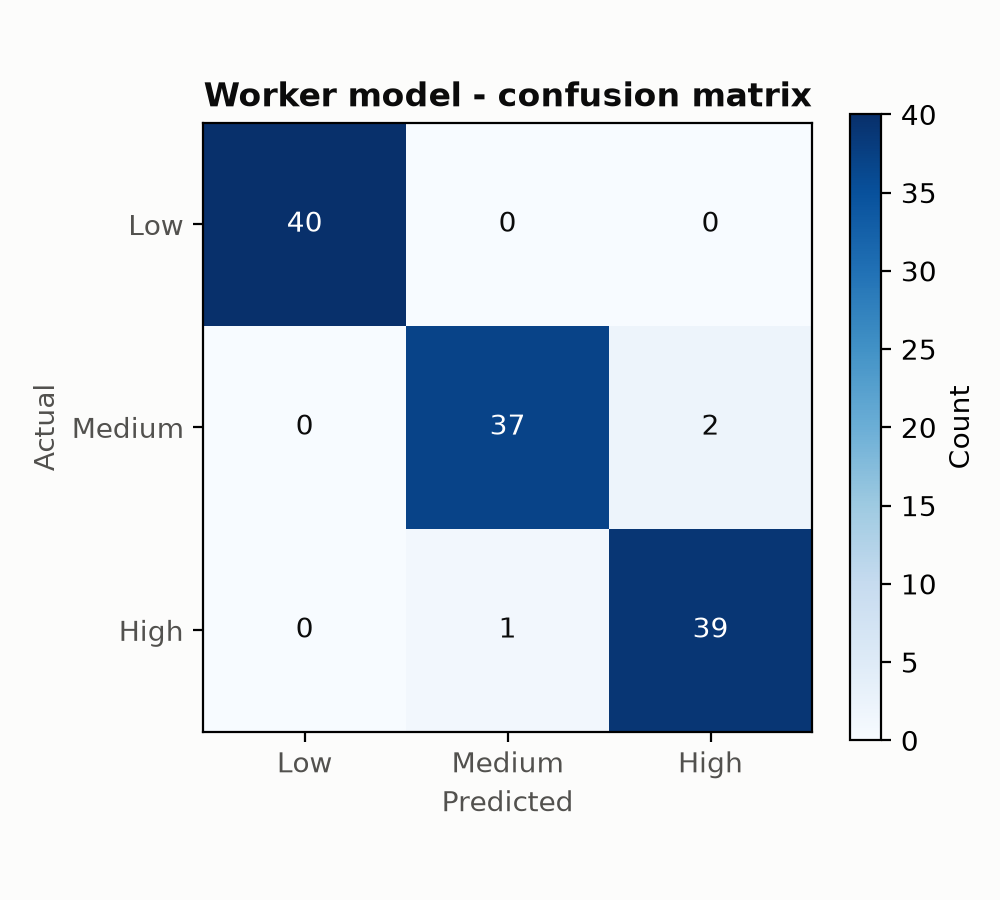

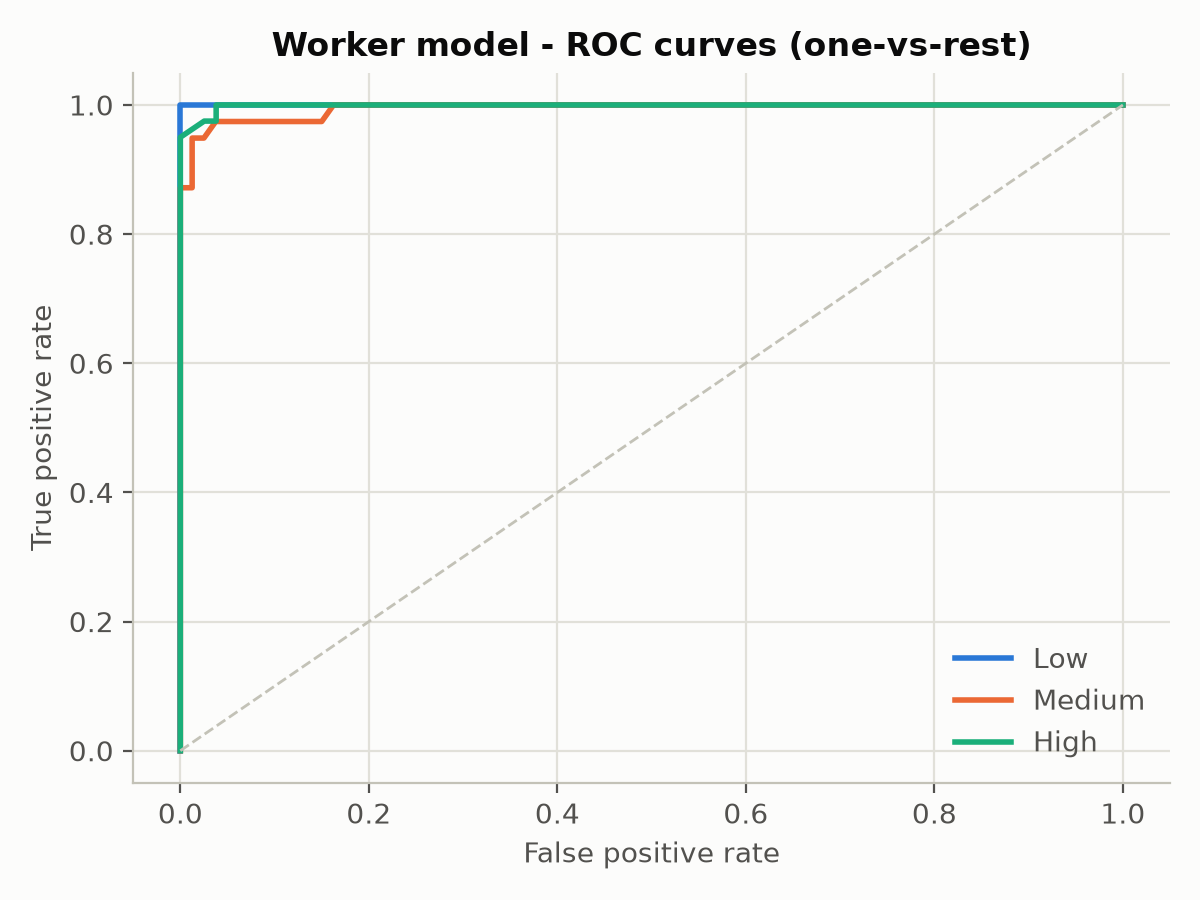

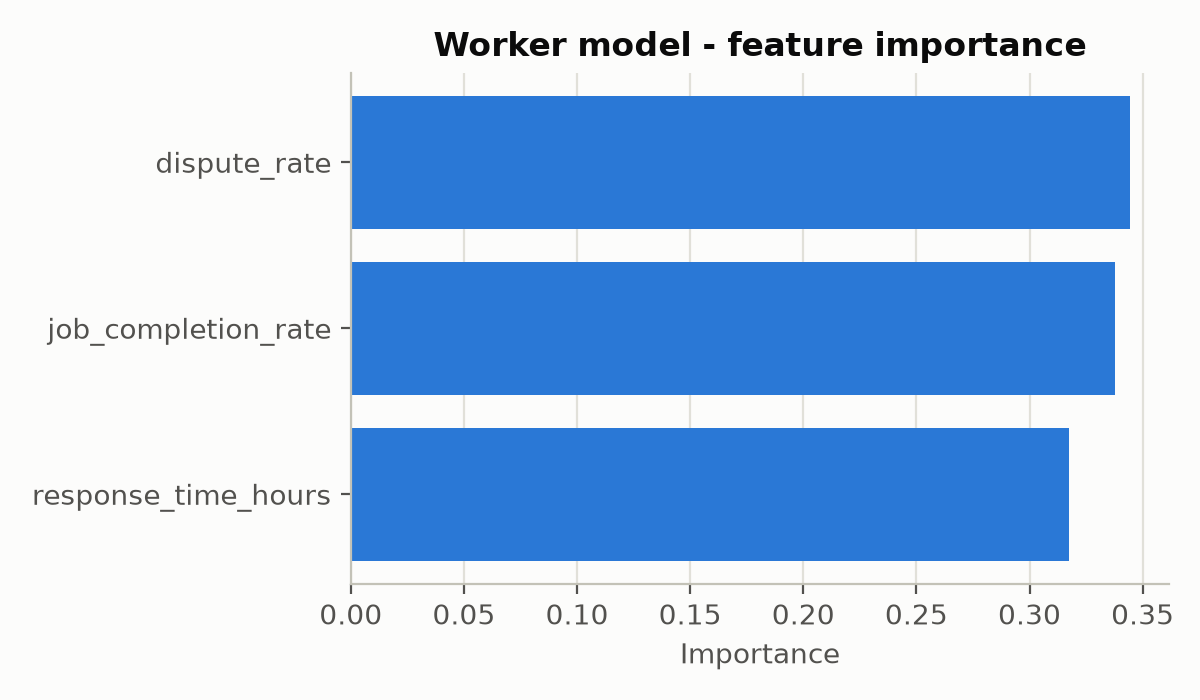

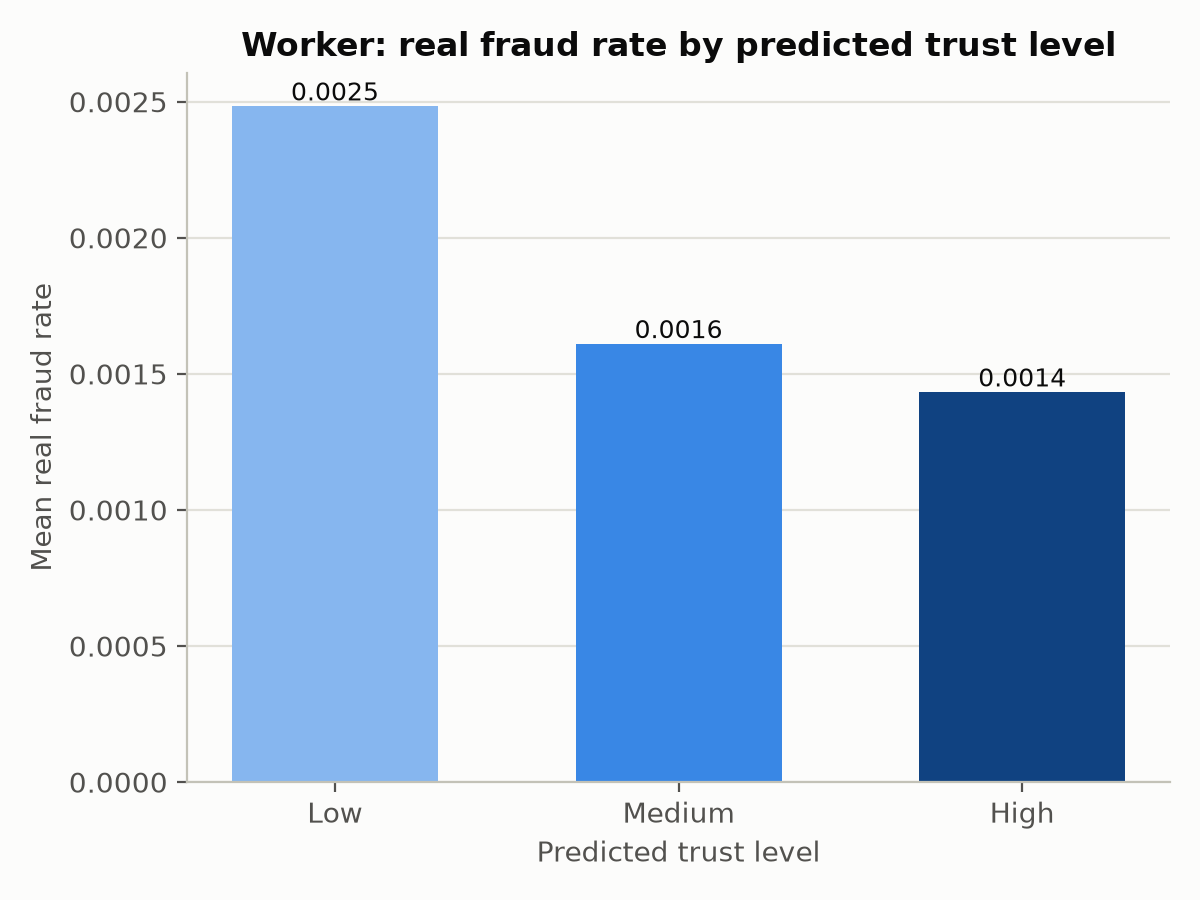

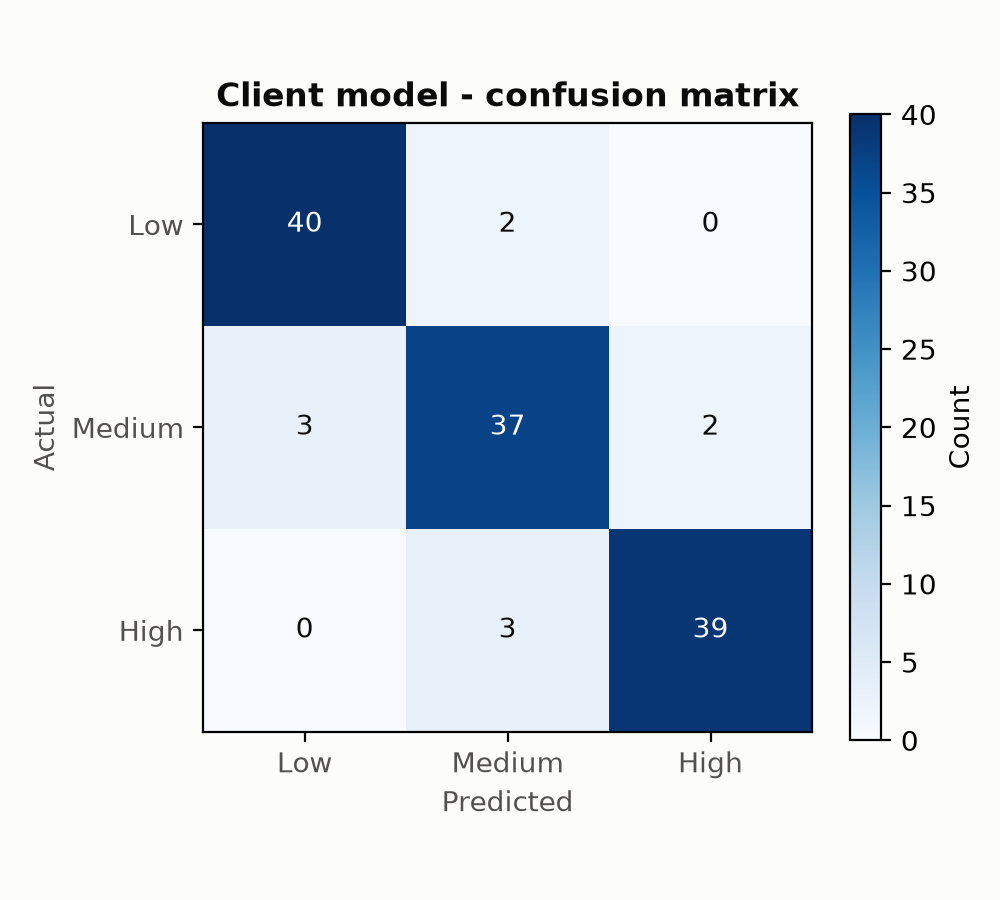

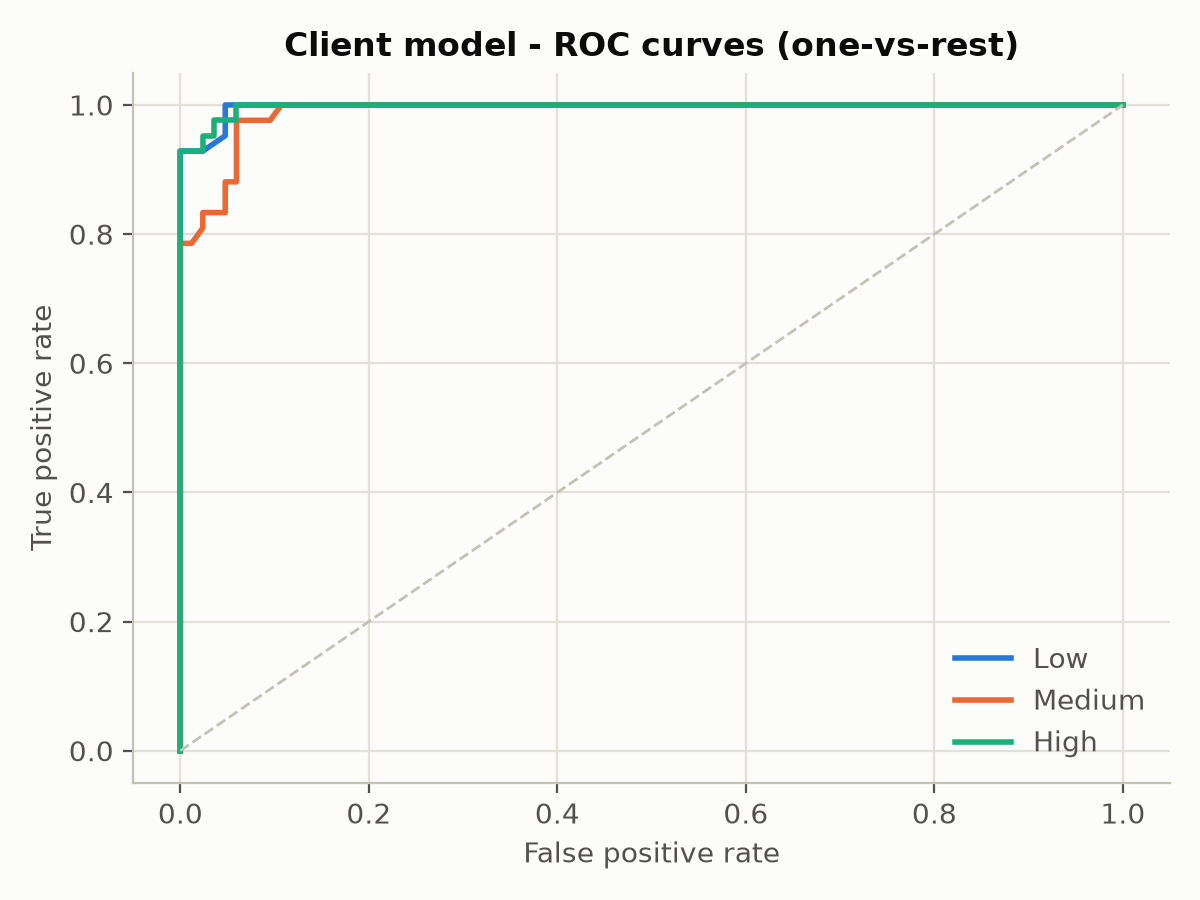

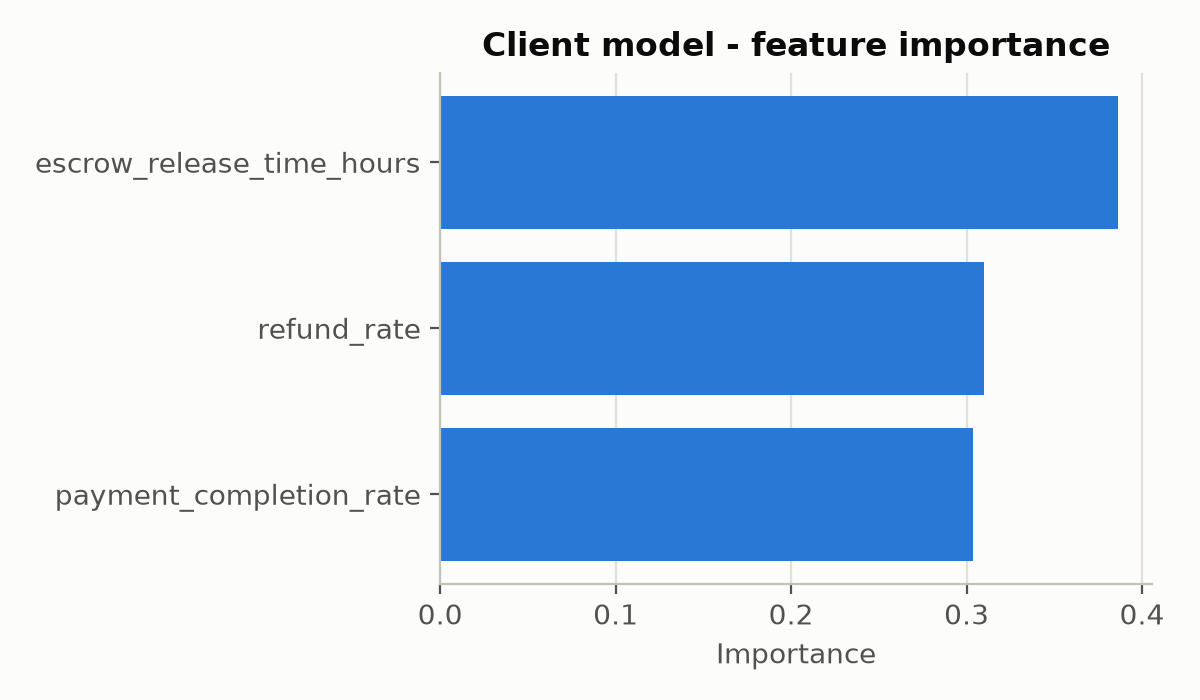

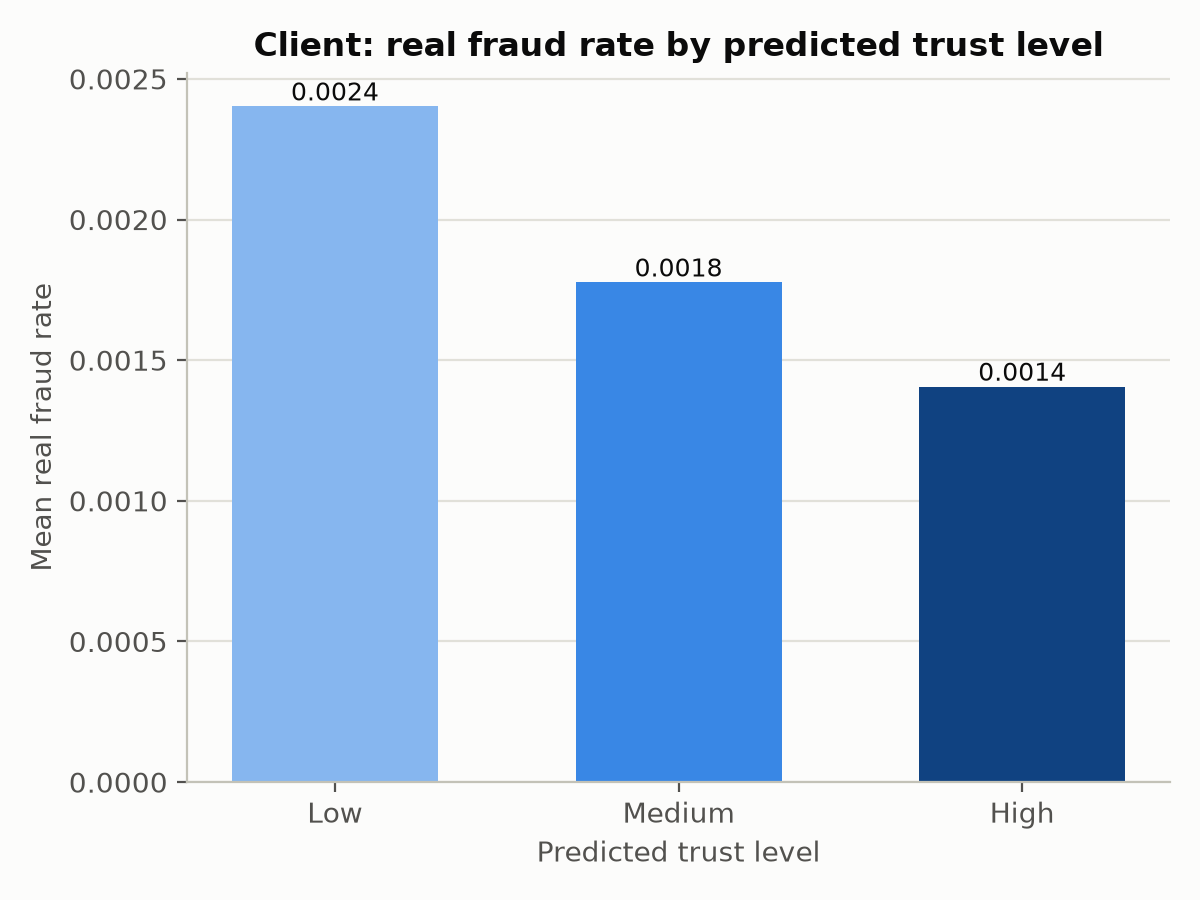

In [7]:
generate_role_figures("Worker", models["worker"], worker_X_test, worker_y_test, WORKER_FEATURE_COLUMNS, fraud_results["worker"], FIGURES_DIR)
generate_role_figures("Client", models["client"], client_X_test, client_y_test, CLIENT_FEATURE_COLUMNS, fraud_results["client"], FIGURES_DIR)

for role in ["worker", "client"]:
    for chart in ["confusion_matrix", "roc_curves", "feature_importance", "fraud_rate_by_trust"]:
        display(Image(filename=str(FIGURES_DIR / f"{role}_{chart}.png"), width=480))

## Interpreting the results

- **Test-set scores** confirm the models learn the trust rule reliably, but because the rule is derived from the same features, they are not evidence of real-world accuracy.
- **The fraud check is the real-world evidence**: trust level moves with independently recorded fraud in the expected direction for both roles.
- **Not yet tested**: whether past behaviour predicts *future* fraud. That needs a time-based split (planned in issue #48) or, ultimately, real platform data.